# Tutorial for running the Python Optimization Toolbox (POPT)

<font size=4em>As an illustrative example we choose a 2D five-spot pattern: one producer at the centre of the field and four (water) injectors, one at each corner. The figure below shows the permeability field and the well positions. The grid is 50x50, and the porosity is 0.2. The optimization problem is to find the water injection rate for each injector, one value per year of the eight-year production period, that maximizes the net present value (NPV).

<img src="../permx.png" alt="drawing" width="500"/>
<br>
<font size=4em>POPT mirrors PIPT: an *ensemble* object owns the control perturbations and the gradient estimate, and an *optimizer* owns its own iteration loop. The first step is to load the necessary external and local modules.


In [1]:
# Import global modules
import os
import shutil
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import local modules
from input_output import read_config                # the config reader
from popt.ensembles import GaussianEnsemble          # control perturbations and gradients
from popt.optimization_methods import LineSearch     # the optimizer; it owns its own loop
from subsurface.multphaseflow.opm import flow        # the simulator we want to use


<font size=4em>Set the random seed:


In [2]:
np.random.seed(10_08_1997)


<font size=4em>Each simulator call runs in its own <span style="font-family:Courier;">En_&lt;member&gt;</span> folder, which it creates with <span style="font-family:Courier;">os.mkdir</span> &mdash; so a folder left behind by an interrupted run makes the next one fail with <span style="font-family:Courier;">FileExistsError</span>. PET clears them when an ensemble is constructed, but not between runs, so we define a helper and call it before each optimization. That keeps the run cells safe to re-execute on their own.


In [3]:
def clean_run_folders(*result_folders):
    """Remove simulator scratch folders, and any results being replaced."""
    for folder in glob('En_*'):
        shutil.rmtree(folder, ignore_errors=True)
    for folder in result_folders:
        shutil.rmtree(folder, ignore_errors=True)


<font size=4em>Read the input file. In this tutorial the input file is written as a .toml file, and consists of three main keys: <span style="font-family:Courier;">ensemble</span>, <span style="font-family:Courier;">optim</span> and <span style="font-family:Courier;">simulator</span>. The first contains keys related to the ensemble of control perturbations, the second the options for the optimization algorithm, and the third the options for the forward simulation model.

<font size=4em>The <span style="font-family:Courier;">ensemble.controls</span> table lists the control variables directly: each entry names one .mako placeholder, together with its mean, standard deviation and bounds. This is a simpler alternative to PIPT's <span style="font-family:Courier;">prior_&lt;name&gt;</span> tables &mdash; there is no need for a separate <span style="font-family:Courier;">state</span> list, since the keys of <span style="font-family:Courier;">controls</span> already give the names.


In [4]:
!cat init_optim.toml
ko, kf, ke = read_config.read('init_optim.toml')
# ko  -->  Optimization settings
# kf  -->  Simulator settings
# ke  -->  Ensemble settings


[ensemble]
    ne = 10
    natural_gradient = false
    [ensemble.controls]
        rate_inj1 = {mean='initrates.npz', std='5%', limits=[0, 500]}
        rate_inj2 = {mean='initrates.npz', std='5%', limits=[0, 500]}
        rate_inj3 = {mean='initrates.npz', std='5%', limits=[0, 500]}
        rate_inj4 = {mean='initrates.npz', std='5%', limits=[0, 500]}

[optim]
    transform = true
    maxiter = 10
    step_size_adapt = 2
    savefolder = 'Results'
    saveit = true

[simulator]
    parallel = 5
    runfile  = '5SPOT'
    datatype = ['FOPT', 'FGPT', 'FWPT', 'FWIT']
    reporttype = 'dates'

    [simulator.reportpoint]
        start = '2000-02-01'
        end = '2008-01-01'
        freq = 'MS'

    [simulator.npv_const]
        wop = 400
        wgp = 0.4
        wwp = 20
        wwi = 10
        disc = 0.08
        obj_scaling = -1.0e9


<font size=4em>Set the initial controls. The filename given as <span style="font-family:Courier;">mean</span> in the input file above must exist before the ensemble is built, and its arrays must match the .mako placeholders <span style="font-family:Courier;">rate_inj1</span>&ndash;<span style="font-family:Courier;">rate_inj4</span>. Each array holds one rate per year of the eight-year schedule, so all four injectors start at a flat 200 Sm3/day.


In [5]:
rate = 8 * [200]
np.savez(
    'initrates.npz',
    rate_inj1=rate,
    rate_inj2=rate,
    rate_inj3=rate,
    rate_inj4=rate,
)


<font size=4em>Define the objective function. This is the one piece POPT does not supply: you hand it any callable that takes the simulated data and returns a scalar to be **minimized**. Here it is the discounted net present value, with the economic constants read from the <span style="font-family:Courier;">npv_const</span> block of the input file.

<font size=4em>Note the <span style="font-family:Courier;">obj_scaling</span> of -1e9: the negative sign turns maximizing NPV into a minimization, and the 1e9 puts the value in billions so the optimizer works on a sensible scale.


In [7]:
DEFAULT_ECON = {
    'wop': 400.0,  # Oil price: $/Sm3
    'wgp': 0.4,    # Gas price: $/Sm3
    'wwp': 20.0,   # Cost of water production per unit volume
    'wwi': 10.0,   # Cost of water injection per unit volume
    'disc': 0.08,  # Discount rate per year
}


def npv(pred_data: pd.DataFrame, **kwargs):
    """Discounted net present value of one simulated production profile."""
    # Economic parameters, from the config's npv_const block if present
    input_dict = kwargs.get('input_dict', {})
    econ = dict(input_dict.get('npv_const', DEFAULT_ECON))
    scaling_factor = econ.pop('obj_scaling', 1.0)

    # Incremental volumes per report step
    vol_oil = pred_data['FOPT'].diff()
    vol_gas = pred_data['FGPT'].diff()
    vol_water_prod = pred_data['FWPT'].diff()
    vol_water_inj = pred_data['FWIT'].diff()

    # Time in years since the start of the run
    time_index = pred_data.index.to_numpy()
    years = (time_index - time_index[0]) / np.timedelta64(365, 'D')

    # Revenue, cost, and discounting
    revenue = vol_oil * econ['wop'] + vol_gas * econ['wgp']
    operating_cost = vol_water_prod * econ['wwp'] + vol_water_inj * econ['wwi']
    discount_factor = (1.0 + econ['disc']) ** years

    return ((revenue - operating_cost) / discount_factor).sum() / scaling_factor


<font size=4em>Initialize the ensemble with the ensemble keys, the simulator and the objective function, then extract the initial control vector (<span style="font-family:Courier;">x0</span>), its covariance (<span style="font-family:Courier;">cov</span>) and the bounds. The ensemble is what turns a non-differentiable simulator into something gradient-based methods can use: it perturbs the controls, runs the simulator on each perturbation, and forms an ensemble approximation of the gradient.


In [8]:
sim = flow(kf)
ensemble = GaussianEnsemble(ke, sim, npv)

x0 = ensemble.get_state()
cov = ensemble.get_cov()
bounds = ensemble.get_bounds()

print(f'controls: {x0}')
print(f'bounds:   {bounds[0]} ... (x{len(bounds)})')


controls: [200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200.]
bounds:   (0, 500) ... (x32)


<font size=4em>Run the optimization with <span style="font-family:Courier;">LineSearch</span>, using BFGS as the search direction. During the run, useful information is written to the screen and to a log file. As in PIPT, there are two ways to do this &mdash; the class-level shortcut that constructs and runs in one call, or an instance you keep and drive yourself.

<font size=4em>The other supported <span style="font-family:Courier;">method</span> values are <span style="font-family:Courier;">'GD'</span> (steepest descent, needs only the gradient) and <span style="font-family:Courier;">'Newton-CG'</span> (needs a Hessian as well, passed as <span style="font-family:Courier;">hess=ensemble.hessian</span>). BFGS builds a curvature estimate from successive gradients, so it needs no Hessian.


In [9]:
clean_run_folders(ko.get('savefolder', 'Results'))

# There are two ways to run the optimization:

# Option 1: the class-level shortcut, when the optimizer object is not needed afterwards
res_bfgs = LineSearch.minimize(
    x0=x0,
    fun=ensemble.function,
    method='BFGS',
    jac=ensemble.gradient,
    args=(cov,),
    bounds=bounds,
    **ko,
)

# Option 2: keep the optimizer, then run it
# ls = LineSearch(x0=x0, fun=ensemble.function, method='BFGS', jac=ensemble.gradient,
#                 args=(cov,), bounds=bounds, **ko)
# res_bfgs = ls.run_optimization()

print(f'NPV: {-res_bfgs.fun:.4f} billion $ after {res_bfgs.nit} iterations')
print(res_bfgs)


2026-08-20│09:04:45 :  ========== Starting Line Search Minimization (BFGS) ==========
2026-08-20│09:04:45 :  
 
USER-SPECIFIED OPTIONS:
       transform: True
         maxiter: 10
 step_size_adapt: 2
      savefolder: Results
          saveit: True
        datatype: ['FOPT', 'FGPT', 'FWPT', 'FWIT']

2026-08-20│09:04:45 :  Computing initial function value...


  0%|                                                                               | 0/1 [00:00<?, ?member/s]

2026-08-20│09:05:03 :  Computing initial jacobian...


  0%|                                                                              | 0/10 [00:00<?, ?member/s]

2026-08-20│09:05:30 : 
2026-08-20│09:05:30 :  ┌────────────┬────────────┬────────────┬────────────┐
2026-08-20│09:05:30 :  │   iter.    │  fun(xₖ)   │ ‖jac(xₖ)‖∞ │ step-size  │
2026-08-20│09:05:30 :  ├────────────┼────────────┼────────────┼────────────┤
2026-08-20│09:05:30 :  │     0      │ -3.230e-01 │ 3.747e-02  │            │
2026-08-20│09:05:30 :  └────────────┴────────────┴────────────┴────────────┘
2026-08-20│09:05:30 : 
2026-08-20│09:05:30 :  Performing line search..........
2026-08-20│09:05:30 :  ──────────────────────────────────────────────────
2026-08-20│09:05:30 :  iteration: 0


...

  0%|                                                                              | 0/10 [00:00<?, ?member/s]

2026-08-20│09:10:48 :      Curvature condition: ❌
2026-08-20│09:10:48 :  iteration: 10
2026-08-20│09:10:48 :      New step-size ──> 3.083e-01


  0%|                                                                               | 0/1 [00:00<?, ?member/s]

2026-08-20│09:10:55 :      Armijo condition: ❌
2026-08-20│09:10:55 :  Line search failed to find a suitable step size
2026-08-20│09:10:55 :  ──────────────────────────────────────────────────
2026-08-20│09:10:55 :  ──────────────────────────────────────────────────
2026-08-20│09:10:55 :  ==========================================================================
2026-08-20│09:10:55 :    Reason for convergence: Line search failed to find a suitable step size
2026-08-20│09:10:55 :    Final function value: -0.3361
2026-08-20│09:10:55 :    Total iterations: 6
2026-08-20│09:10:55 :    Total function evaluations: 23
2026-08-20│09:10:55 :    Total jacobian evaluations: 8
2026-08-20│09:10:55 :  ==========================================================================


NPV: 0.3361 billion $ after 5 iterations
 message: Line search failed to find a suitable step size
     fun: -0.336094609307343
       x: [ 4.030e+02  3.913e+02 ...  2.752e+02  1.599e+02]
     nit: 5
     jac: [-8.864e-06 -7.623e-06 ...  8.781e-07 -7.724e-08]
    hess: None
    nfev: 12
    njev: 6
    nhev: 0


<font size=4em>Plot the objective function against iteration. The optimizer writes one file per iteration, <span style="font-family:Courier;">optimize_result_{i}.npz</span>, into the folder named by the <span style="font-family:Courier;">savefolder</span> key &mdash; the counterpart of PIPT's <span style="font-family:Courier;">assimilation_result_{i}.npz</span>. Saving happens only when <span style="font-family:Courier;">saveit</span> is true.


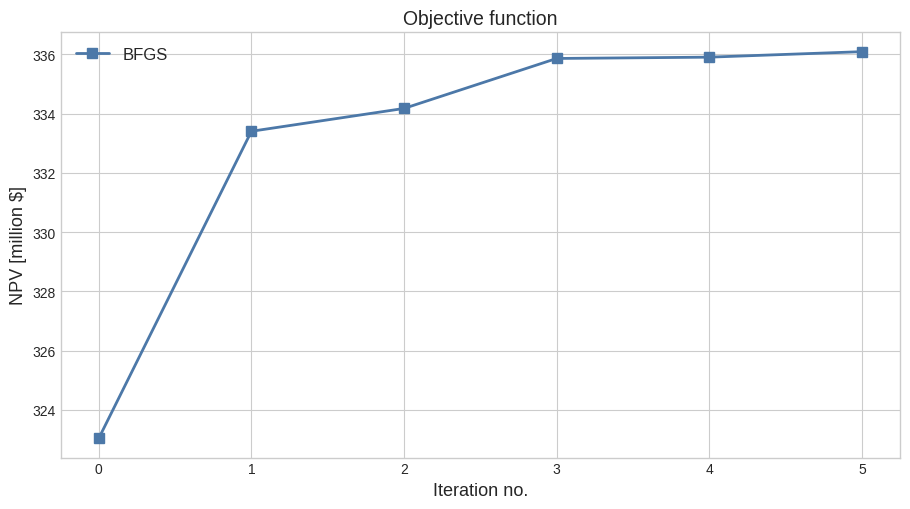

In [10]:
def read_npv_history(folder):
    """Collect the NPV, in million $, at each iteration from the saved result files."""
    values = []
    it = 0
    while True:
        file = f'{folder}/optimize_result_{it}.npz'
        if not os.path.exists(file):
            break
        info = np.load(file)
        # 'fun' is the objective value at that iteration, in billion $ with a flipped sign
        # (obj_scaling = -1e9). Undo both to get NPV in million $.
        values.append(-1000.0 * float(np.mean(info['fun'])))
        it += 1
    return values


npv_bfgs = read_npv_history(ko.get('savefolder', 'Results'))

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9.2, 5.2), facecolor='white')
ax.plot(npv_bfgs, 's-', color='#4C78A8', linewidth=2, markersize=7, label='BFGS')
ax.set_xlabel('Iteration no.', size=13)
ax.set_ylabel('NPV [million $]', size=13)
ax.set_title('Objective function', size=14)
ax.set_xticks(range(len(npv_bfgs)))
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()


<font size=4em>The same problem with a different search direction. <span style="font-family:Courier;">method='GD'</span> takes a plain steepest-descent step instead of the BFGS quasi-Newton direction &mdash; simpler, but it does not accumulate curvature information across iterations, so it typically needs more of them to reach the same NPV. Everything else &mdash; the ensemble, the objective, the bounds &mdash; is reused unchanged, which is the point of keeping the optimizer separate from the ensemble.

<font size=4em>Both runs start from the same <span style="font-family:Courier;">x0</span> captured above, so the comparison is fair. Note that <span style="font-family:Courier;">ensemble.get_state()</span> would <em>not</em> do here: it returns the ensemble's current controls, which the first optimization has already moved.


In [11]:
from copy import deepcopy

ko_gd = deepcopy(ko)
ko_gd['savefolder'] = 'Results_gd'   # keep the BFGS files for the comparison below

clean_run_folders(ko_gd['savefolder'])

res_gd = LineSearch.minimize(
    x0=x0,
    fun=ensemble.function,
    method='GD',
    jac=ensemble.gradient,
    args=(cov,),
    bounds=bounds,
    **ko_gd,
)

print(f'NPV: {-res_gd.fun:.4f} billion $ after {res_gd.nit} iterations')


2026-08-20│09:12:08 :  ========== Starting Line Search Minimization (GD) ==========
2026-08-20│09:12:08 :  
 
USER-SPECIFIED OPTIONS:
       transform: True
         maxiter: 10
 step_size_adapt: 2
      savefolder: Results_gd
          saveit: True
        datatype: ['FOPT', 'FGPT', 'FWPT', 'FWIT']

2026-08-20│09:12:08 :  Computing initial function value...


  0%|                                                                               | 0/1 [00:00<?, ?member/s]

2026-08-20│09:12:14 :  Computing initial jacobian...


  0%|                                                                              | 0/10 [00:00<?, ?member/s]

2026-08-20│09:12:34 : 
2026-08-20│09:12:34 :  ┌────────────┬────────────┬────────────┬────────────┐
2026-08-20│09:12:34 :  │   iter.    │  fun(xₖ)   │ ‖jac(xₖ)‖∞ │ step-size  │
2026-08-20│09:12:34 :  ├────────────┼────────────┼────────────┼────────────┤
2026-08-20│09:12:34 :  │     0      │ -3.230e-01 │ 1.831e-02  │            │
2026-08-20│09:12:34 :  └────────────┴────────────┴────────────┴────────────┘
2026-08-20│09:12:34 : 
2026-08-20│09:12:34 :  Performing line search..........
2026-08-20│09:12:34 :  ──────────────────────────────────────────────────
2026-08-20│09:12:34 :  iteration: 0


...

  0%|                                                                               | 0/1 [00:00<?, ?member/s]

2026-08-20│09:18:02 :      Armijo condition: ✅


  0%|                                                                              | 0/10 [00:00<?, ?member/s]

2026-08-20│09:18:21 :      Curvature condition: ✅
2026-08-20│09:18:21 :  ──────────────────────────────────────────────────
2026-08-20│09:18:21 : 
2026-08-20│09:18:21 :  ┌────────────┬────────────┬────────────┬────────────┐
2026-08-20│09:18:21 :  │   iter.    │  fun(xₖ)   │ ‖jac(xₖ)‖∞ │ step-size  │
2026-08-20│09:18:21 :  ├────────────┼────────────┼────────────┼────────────┤
2026-08-20│09:18:21 :  │     10     │ -3.400e-01 │ 5.186e-03  │ 1.321e+01  │
2026-08-20│09:18:21 :  └────────────┴────────────┴────────────┴────────────┘
2026-08-20│09:18:21 : 
2026-08-20│09:18:21 :  ==========================================================================
2026-08-20│09:18:21 :    Reason for convergence: Maximum number of iterations reached
2026-08-20│09:18:21 :    Final function value: -0.3400
2026-08-20│09:18:21 :    Total iterations: 10
2026-08-20│09:18:21 :    Total function evaluations: 15
2026-08-20│09:18:21 :    Total jacobian evaluations: 11
2026-08-20│09:18:21 :  =========================

NPV: 0.3400 billion $ after 10 iterations


<font size=4em>Compare the two:


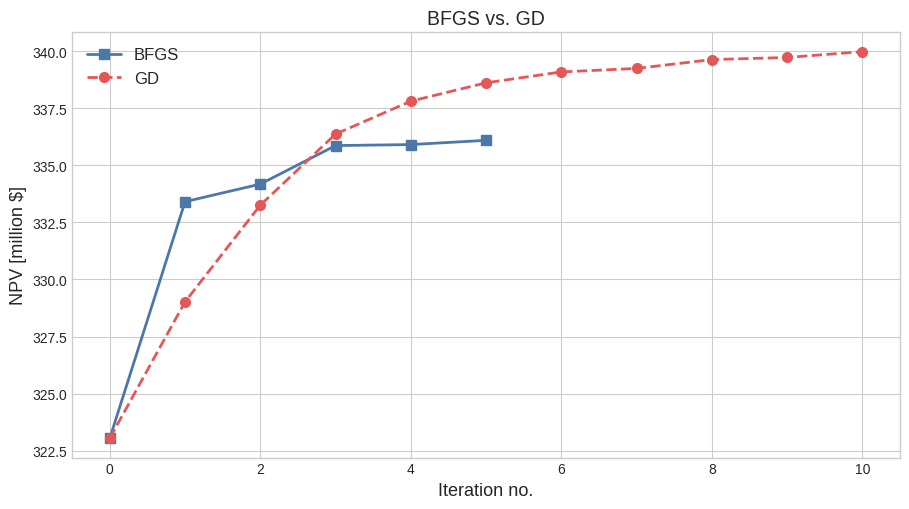

In [12]:
npv_gd = read_npv_history(ko_gd['savefolder'])

fig, ax = plt.subplots(figsize=(9.2, 5.2), facecolor='white')
ax.plot(npv_bfgs, 's-', color='#4C78A8', linewidth=2, markersize=7, label='BFGS')
ax.plot(npv_gd, 'o--', color='#E45756', linewidth=2, markersize=7, label='GD')
ax.set_xlabel('Iteration no.', size=13)
ax.set_ylabel('NPV [million $]', size=13)
ax.set_title('BFGS vs. GD', size=14)
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()


## Setting up the .mako file
<font size=4em>The optimization relies on a .mako file for writing the current control variables to the flow simulator input. In this case, the flow simulator is opm-flow [opm-projects.org](opm-projects.org), and the input file is provided as a text file (.DATA file). Once a year, the .mako file writes a <span style="font-family:Courier;">WCONINJE</span> block that sets that year's rate for each injector:

    WCONINJE
    INJ1 WATER OPEN RATE ${rate_inj1[index]} 1* 500.0  /
    INJ2 WATER OPEN RATE ${rate_inj2[index]} 1* 500.0  /
    INJ3 WATER OPEN RATE ${rate_inj3[index]} 1* 500.0  /
    INJ4 WATER OPEN RATE ${rate_inj4[index]} 1* 500.0  /
    /

<font size=4em>The names <span style="font-family:Courier;">rate_inj1</span>&ndash;<span style="font-family:Courier;">rate_inj4</span> are the keys of the <span style="font-family:Courier;">ensemble.controls</span> table in the input file, so the .mako placeholders and the config have to agree. The producer's bottom-hole pressure is fixed for the whole run and is not a control.


## Running locally

<font size=4em>It is recommended to run the notebook from a virtual environment. Follow these steps to run this notebook on your own computer:

<font size=4em>*Step 1: Create virtual environment as normal*

    python3 -m venv pet_venv

<font size=4em>Then activate the environment using:

    source pet_venv/bin/activate

<font size=4em>*Step 2: Install Jupyter Notebook into virtual environment*

    python3 -m pip install ipykernel

<font size=4em>*Step 3: Install PET in the virtual environment, see [PET installation](https://github.com/Python-Ensemble-Toolbox/PET)*

<font size=4em>*Step 4: Allow Jupyter access to the kernel within the virtual environment*

    python3 -m ipykernel install --user --name=pet_venv

<font size=4em>Start jupyter notebook, and load tutorial_popt.ipynb (this file). On the jupyter notebook toolbar, select 'Kernel' and 'Change Kernel'.
